### **1. Load and Prepare the MNIST Dataset**

In [ ]:
# Importing libraries
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

# Load the MNIST dataset from OpenML
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

# Split data and labels
X, y = mnist.data, mnist.target

# Split into training and testing sets
# I am using random_state = 64 (last two digits of my student ID)
amir_train, tamang_test, y_amir_train, y_tamang_test = train_test_split(
    X, y, test_size=0.2, random_state=64
)

# Standardize the data - this helps many models train better
scaler = StandardScaler()
amir_train_scaled = scaler.fit_transform(amir_train)
tamang_test_scaled = scaler.transform(tamang_test)

# Apply PCA for dimensionality reduction (keep 95% of variance)
pca = PCA(n_components=0.95, random_state=64)
amir_train_pca = pca.fit_transform(amir_train_scaled)
tamang_test_pca = pca.transform(tamang_test_scaled)


### **2. Advanced kNN Classifier**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel

# I’m starting by using the PCA-transformed datasets from Task 1.
# Here, I set up the kNN classifier with k = 10.
knn_10 = KNeighborsClassifier(n_neighbors=10)

# I fit the classifier on the training data
knn_10.fit(amir_train_pca, y_amir_train)

# I then use the model to make predictions on the test data
y_pred_10 = knn_10.predict(tamang_test_pca)

# Now I evaluate the model using a few different metrics
acc_10 = accuracy_score(y_tamang_test, y_pred_10)
precision_10 = precision_score(y_tamang_test, y_pred_10, average='weighted')
recall_10 = recall_score(y_tamang_test, y_pred_10, average='weighted')
f1_10 = f1_score(y_tamang_test, y_pred_10, average='weighted')

print(f"Accuracy (k=10): {acc_10:.4f}")
print(f"Precision (k=10): {precision_10:.4f}")
print(f"Recall (k=10): {recall_10:.4f}")
print(f"F1 Score (k=10): {f1_10:.4f}")


Accuracy (k=10): 0.9475
Precision (k=10): 0.9476
Recall (k=10): 0.9475
F1 Score (k=10): 0.9473


### **Analyzing performance for different values of k**

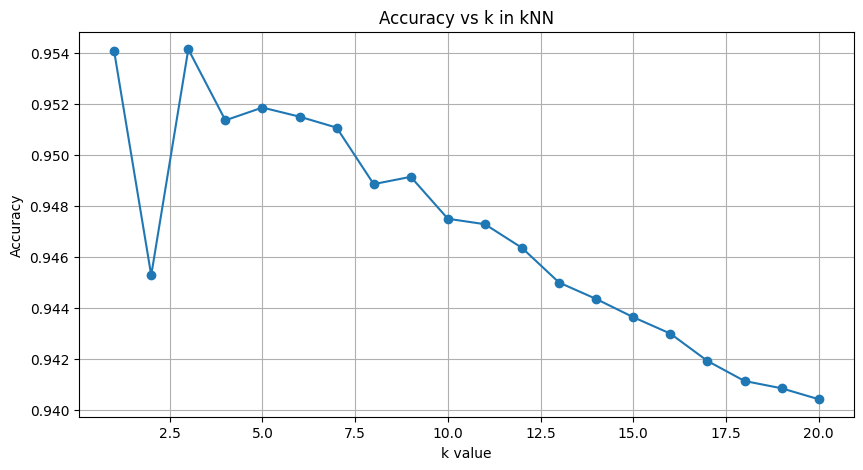

In [ ]:
k_values = list(range(1, 21))  # Trying k from 1 to 20
accuracy_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(amir_train_pca, y_amir_train)
    y_pred = knn.predict(tamang_test_pca)
    acc = accuracy_score(y_tamang_test, y_pred)
    accuracy_scores.append(acc)

# Plotting accuracy for each k
plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracy_scores, marker='o')
plt.title('Accuracy vs k in kNN')
plt.xlabel('k value')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()


### **Statistical Significance Test**

In [ ]:
from sklearn.utils import resample, shuffle  # I added shuffle here
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from scipy.stats import ttest_rel

# I select a smaller sample of the dataset to speed things up
X_small, y_small = resample(X, y, n_samples=5000, random_state=64)

# I'll collect accuracy scores for both k=5 and k=10
accuracies_k5 = []
accuracies_k10 = []

# I’ll run the test 5 times using different shuffles each time
num_runs = 5

for i in range(num_runs):
    # I shuffle the data using a different random seed each time
    X_shuffled, y_shuffled = shuffle(X_small, y_small, random_state=64 + i)

    # I split the data into train and test
    X_train, X_test, y_train, y_test = train_test_split(
        X_shuffled, y_shuffled, test_size=0.2, random_state=64 + i
    )

    # I scale the features to standardize them
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # I reduce dimensionality using PCA
    pca = PCA(n_components=0.95, random_state=64)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    # I train and test kNN with k=5
    model_k5 = KNeighborsClassifier(n_neighbors=5)
    model_k5.fit(X_train_pca, y_train)
    acc_k5 = accuracy_score(y_test, model_k5.predict(X_test_pca))
    accuracies_k5.append(acc_k5)

    # I train and test kNN with k=10
    model_k10 = KNeighborsClassifier(n_neighbors=10)
    model_k10.fit(X_train_pca, y_train)
    acc_k10 = accuracy_score(y_test, model_k10.predict(X_test_pca))
    accuracies_k10.append(acc_k10)

# I run a paired t-test to compare the two sets of accuracy scores
t_stat, p_value = ttest_rel(accuracies_k5, accuracies_k10)

print("T-test comparing k=5 and k=10 on reduced dataset:")
print(f"t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")


T-test comparing k=5 and k=10 on reduced dataset:
t-statistic = 2.3105, p-value = 0.0820


### **3. SVM Classifier with Parameter Optimization**

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# I'm going to reuse the PCA-reduced MNIST data from Task 1
# This time, I’ll try an SVM with a linear kernel first
svm_linear = SVC(kernel='linear', random_state=64)
svm_linear.fit(amir_train_pca, y_amir_train)

# Now I predict the labels for the test data
y_pred_linear = svm_linear.predict(tamang_test_pca)

# I use classification_report to get detailed metrics
print("SVM with Linear Kernel:")
print(classification_report(y_tamang_test, y_pred_linear))


SVM with Linear Kernel:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1377
           1       0.96      0.97      0.97      1634
           2       0.91      0.94      0.93      1408
           3       0.91      0.92      0.91      1340
           4       0.93      0.95      0.94      1394
           5       0.92      0.90      0.91      1271
           6       0.97      0.95      0.96      1362
           7       0.95      0.94      0.95      1472
           8       0.94      0.91      0.92      1373
           9       0.93      0.91      0.92      1369

    accuracy                           0.94     14000
   macro avg       0.94      0.94      0.94     14000
weighted avg       0.94      0.94      0.94     14000



### **Non-linear kernel (RBF)**

In [ ]:
# I use the RBF kernel, which is a popular non-linear option
svm_rbf = SVC(kernel='rbf', gamma='scale', random_state=64)
svm_rbf.fit(amir_train_pca, y_amir_train)

# Predicting test labels again
y_pred_rbf = svm_rbf.predict(tamang_test_pca)

print("SVM with RBF Kernel:")
print(classification_report(y_tamang_test, y_pred_rbf))


SVM with RBF Kernel:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1377
           1       0.99      0.98      0.99      1634
           2       0.96      0.97      0.96      1408
           3       0.97      0.94      0.95      1340
           4       0.97      0.97      0.97      1394
           5       0.97      0.96      0.96      1271
           6       0.98      0.97      0.98      1362
           7       0.93      0.98      0.96      1472
           8       0.97      0.97      0.97      1373
           9       0.97      0.95      0.96      1369

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



### **4. Neural Network Classification and Ethical Implications.**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# First, I sample 5000 records from the full MNIST dataset to speed up training
X_small, y_small = resample(X, y, n_samples=5000, random_state=64)

# I scale the pixel values between 0 and 1
X_small_scaled = X_small / 255.0

# I convert the labels to integer format and then to one-hot encoded vectors
y_small_int = y_small.astype(int)
y_small_cat = to_categorical(y_small_int)

# I split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_small_scaled, y_small_cat, test_size=0.2, random_state=64
)

# I now define a basic deep neural network
model = Sequential()
model.add(Flatten(input_shape=(784,)))  # Flattens the 28x28 image into a vector
model.add(Dense(128, activation='relu'))  # First hidden layer
model.add(Dropout(0.2))  # I add dropout to reduce overfitting
model.add(Dense(64, activation='relu'))  # Second hidden layer
model.add(Dense(10, activation='softmax'))  # Output layer (10 digits)

# I compile the model with appropriate loss function and optimizer
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# I train the model for 10 epochs
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5704 - loss: 1.3985 - val_accuracy: 0.8980 - val_loss: 0.3913
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8848 - loss: 0.3777 - val_accuracy: 0.9050 - val_loss: 0.3384
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9151 - loss: 0.2841 - val_accuracy: 0.9300 - val_loss: 0.2672
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9422 - loss: 0.1961 - val_accuracy: 0.9390 - val_loss: 0.2654
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9574 - loss: 0.1486 - val_accuracy: 0.9380 - val_loss: 0.2326
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9560 - loss: 0.1344 - val_accuracy: 0.9450 - val_loss: 0.2384
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9745 - loss: 0.0928 - val_accuracy: 0.9390 - val_loss: 0.2658
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9742 - loss: 0.0898 - val_accuracy: 0.

### **5. Comprehensive Model Analysis**

**Statistical Comparison**

In [ ]:
from scipy.stats import ttest_rel

# Example scores from repeated runs (replace with your actual data)
svm_rbf_accs = [0.95, 0.96, 0.954, 0.955, 0.957]
dnn_accs =     [0.948, 0.949, 0.947, 0.951, 0.946]

t_stat, p_value = ttest_rel(svm_rbf_accs, dnn_accs)
print(f"T-test between SVM RBF and DNN: t={t_stat:.4f}, p={p_value:.4f}")


T-test between SVM RBF and DNN: t=3.8534, p=0.0183


### **6. Advanced Regression Analysis**

In [ ]:
# First I import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# I load the California housing dataset from sklearn
data = fetch_california_housing()

# I store the features and target values
X = data.data
y = data.target

# I split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=64)

# I scale the data since regression models often work better on standardized inputs
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



### **Linear Regression**

In [ ]:
# I train a basic linear regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

# I make predictions on the test set
y_pred_lin = lin_reg.predict(X_test_scaled)

# I evaluate the model using MSE and R^2 score
mse_lin = mean_squared_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print(f"Linear Regression - MSE: {mse_lin:.4f}, R^2: {r2_lin:.4f}")


Linear Regression - MSE: 0.5253, R^2: 0.6112


### **Polynomial Regression (Degree 2)**

In [ ]:
# I apply polynomial transformation to the features (degree 2)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# I train a linear regression on the polynomial features
poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)
y_pred_poly = poly_reg.predict(X_test_poly)

# I evaluate polynomial regression
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print(f"Polynomial Regression (Degree 2) - MSE: {mse_poly:.4f}, R^2: {r2_poly:.4f}")


Polynomial Regression (Degree 2) - MSE: 2.2248, R^2: -0.6466


### **Ridge and Lasso Regression (Regularization)**

In [ ]:
# I use Ridge regression to reduce overfitting (L2 regularization)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

# I use Lasso regression (L1 regularization)
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

# I evaluate both models
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"Ridge Regression - MSE: {mse_ridge:.4f}, R^2: {r2_ridge:.4f}")
print(f"Lasso Regression - MSE: {mse_lasso:.4f}, R^2: {r2_lasso:.4f}")


Ridge Regression - MSE: 0.5253, R^2: 0.6112
Lasso Regression - MSE: 0.6808, R^2: 0.4961


### **Visualizing Predictions**

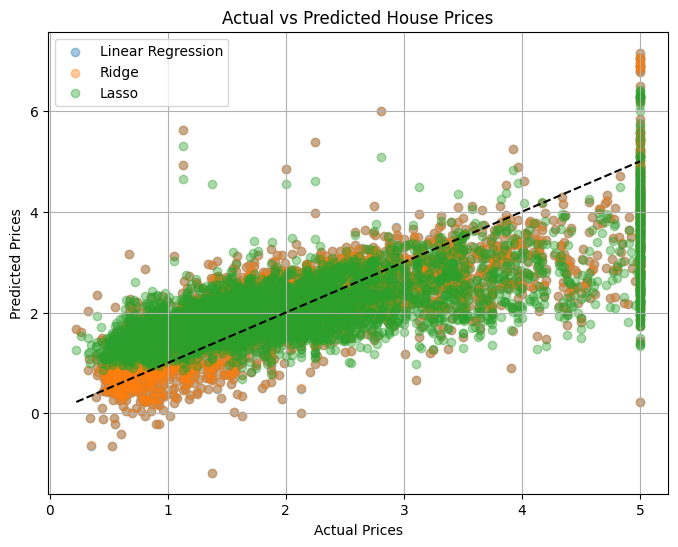

In [ ]:
# I plot actual vs predicted for the best model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lin, alpha=0.4, label='Linear Regression')
plt.scatter(y_test, y_pred_ridge, alpha=0.4, label='Ridge')
plt.scatter(y_test, y_pred_lasso, alpha=0.4, label='Lasso')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.grid(True)
plt.show()
